# 02 — Concisão e foco

A correção (notebook 01) mostrou modelos quase empatados. Aqui investigamos a outra
metade da experiência do usuário: **a resposta foi entregue de forma útil ou despejou
informação não pedida?**

Variável principal: `concisao_score` ∈ {0, 1}
- **1** = resposta concisa, focada no que foi perguntado
- **0** = resposta correta porém com despejo de informação extra não pedida

Diferente do estudo anterior, aqui a concisão **não é derivada do número de tokens**:
ela vem da avaliação de um juiz LLM com justificativa (campo `justificativa_concisao`).

Perguntas guia:
1. Quem é mais conciso? Há padrão por provedor?
2. Concisão correlaciona com tamanho da resposta?
3. Resposta concisa "perde" correção?
4. Que padrões aparecem nas justificativas de concisão = 0?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from pathlib import Path
from scipy import stats
import re
from collections import Counter

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 150,
    'font.size': 10, 'axes.titleweight': 'bold', 'axes.titlesize': 12,
})

PALETA_PROVEDOR = {'anthropic': '#D97757', 'openai': '#10A37F', 'deepseek': '#4D6BFE'}
PALETA_ORIGEM   = {'ferramenta': '#2E86AB', 'chat_comercial': '#E74C3C'}
CORES_NOTA = {0.0: '#E74C3C', 0.5: '#F39C12', 1.0: '#2ECC71'}

def detecta_artefatos():
    candidatos = [Path('../artefatos'), Path('../../artefatos'), Path('artefatos'),
                  Path('../'), Path('.')]
    for c in candidatos:
        if (c / 'result_unificado_final.xlsx').exists():
            return c.resolve()
    raise FileNotFoundError('result_unificado_final.xlsx não encontrado.')

ART = detecta_artefatos()
print(f'Artefatos em: {ART}')

def infere_provedor(modelo: str) -> str:
    m = modelo.lower()
    if 'claude' in m: return 'anthropic'
    if 'gpt' in m or 'chatgpt' in m: return 'openai'
    if 'deepseek' in m: return 'deepseek'
    return 'desconhecido'

df = pd.read_excel(ART / 'result_unificado_final.xlsx')
df['provedor'] = df['modelo'].apply(infere_provedor)
print(f'{len(df)} respostas — concisao_score já populado para todas as 1650 linhas')


Artefatos em: /home/julio/Documentos/tcc_GENAI/v8/edital-assistant/eval/artefatos
1650 respostas — concisao_score já populado para todas as 1650 linhas


## 1. Visão geral da concisão por modelo

`concisao_score` é binário ⇒ a métrica natural é a **taxa de respostas concisas**.


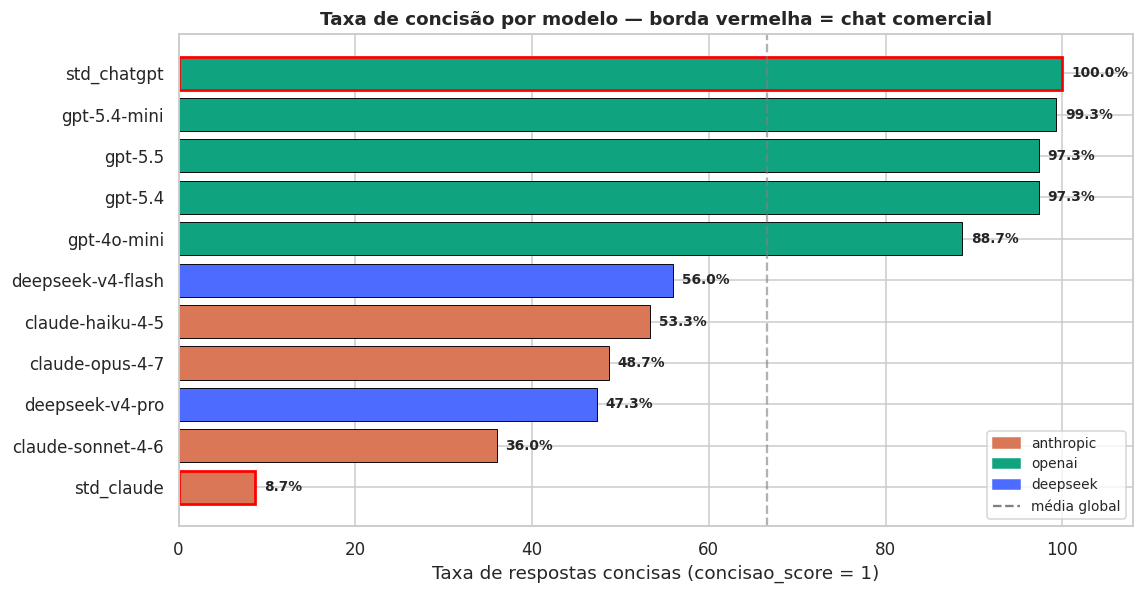


            modelo  taxa_concisa   n  provedor         origem
       std_claude         0.087 150 anthropic chat_comercial
claude-sonnet-4-6         0.360 150 anthropic     ferramenta
  deepseek-v4-pro         0.473 150  deepseek     ferramenta
  claude-opus-4-7         0.487 150 anthropic     ferramenta
 claude-haiku-4-5         0.533 150 anthropic     ferramenta
deepseek-v4-flash         0.560 150  deepseek     ferramenta
      gpt-4o-mini         0.887 150    openai     ferramenta
          gpt-5.4         0.973 150    openai     ferramenta
          gpt-5.5         0.973 150    openai     ferramenta
     gpt-5.4-mini         0.993 150    openai     ferramenta
      std_chatgpt         1.000 150    openai chat_comercial


In [2]:
rank_conc = (df.groupby('modelo')
             .agg(taxa_concisa=('concisao_score','mean'),
                  n=('concisao_score','count'),
                  provedor=('provedor','first'),
                  origem=('origem_resultado','first'))
             .reset_index().sort_values('taxa_concisa', ascending=True))

fig, ax = plt.subplots(figsize=(10.5, max(5, 0.5*len(rank_conc))))
cores = [PALETA_PROVEDOR[p] for p in rank_conc['provedor']]
edges = ['black' if o=='ferramenta' else 'red' for o in rank_conc['origem']]
lw    = [0.6 if o=='ferramenta' else 1.8 for o in rank_conc['origem']]
bars = ax.barh(rank_conc['modelo'], rank_conc['taxa_concisa']*100,
               color=cores, edgecolor=edges, linewidth=lw)
for b, v in zip(bars, rank_conc['taxa_concisa']*100):
    ax.text(v+1, b.get_y()+b.get_height()/2, f'{v:.1f}%',
            va='center', fontsize=9, fontweight='bold')
ax.axvline(df.concisao_score.mean()*100, ls='--', color='gray', alpha=0.6,
           label=f'média global = {df.concisao_score.mean()*100:.1f}%')
ax.set_xlabel('Taxa de respostas concisas (concisao_score = 1)')
ax.set_title('Taxa de concisão por modelo — borda vermelha = chat comercial')
ax.set_xlim(0, 108)
patches = [mpatches.Patch(color=c, label=p) for p,c in PALETA_PROVEDOR.items()]
ax.legend(handles=patches + [plt.Line2D([0],[0], color='gray', ls='--', label='média global')],
          loc='lower right', fontsize=9)
plt.tight_layout(); plt.show()

print('\n', rank_conc.round(3).to_string(index=False))


## 2. Concisão por provedor

Agregando ferramentas API por provedor (Anthropic, OpenAI, DeepSeek) e comparando
com os chats comerciais.


origem_resultado  provedor  taxa_concisa  score_correcao  tokens_resposta   n
  chat_comercial anthropic         0.087           0.950          581.413 150
  chat_comercial    openai         1.000           0.877           61.100 150
      ferramenta anthropic         0.460           0.962          274.989 450
      ferramenta  deepseek         0.517           0.967          280.513 300
      ferramenta    openai         0.957           0.944          116.368 600


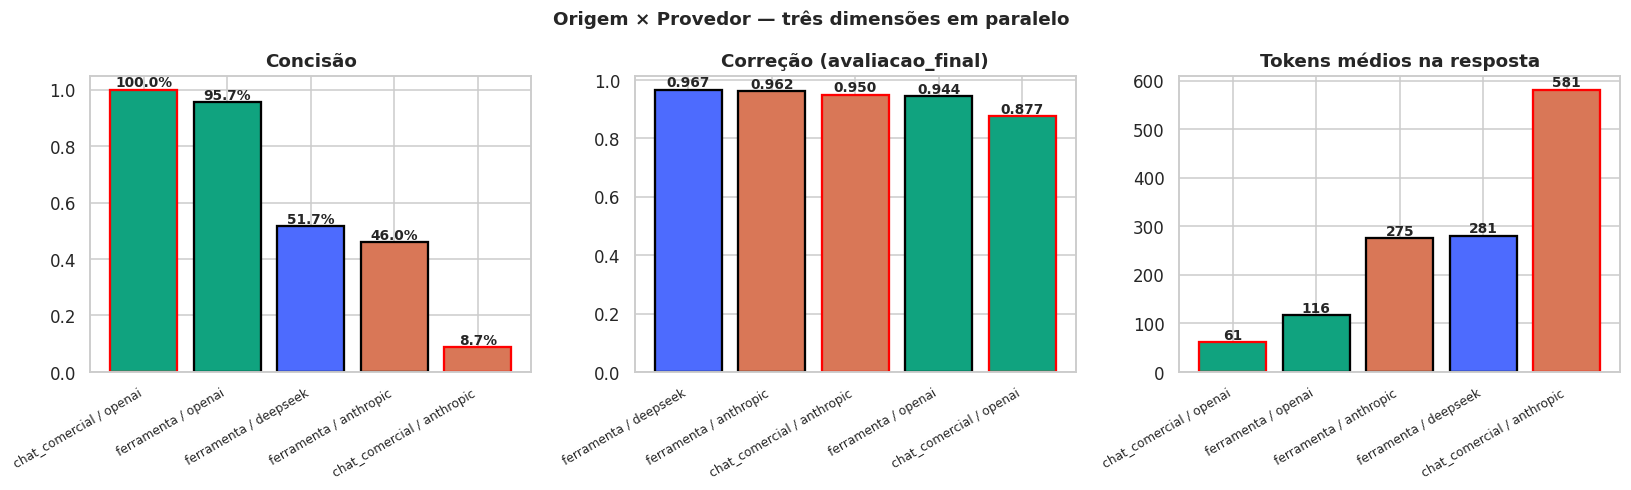

In [3]:
prov_summary = (df.groupby(['origem_resultado','provedor'])
                .agg(taxa_concisa=('concisao_score','mean'),
                     score_correcao=('avaliacao_final','mean'),
                     tokens_resposta=('resposta_tokens_tiktoken','mean'),
                     n=('concisao_score','count'))
                .round(3).reset_index())
print(prov_summary.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col, titulo, fmt in zip(
    axes,
    ['taxa_concisa','score_correcao','tokens_resposta'],
    ['Concisão','Correção (avaliacao_final)','Tokens médios na resposta'],
    ['{:.1%}','{:.3f}','{:.0f}']
):
    sub = prov_summary.copy()
    sub['label'] = sub['origem_resultado'] + ' / ' + sub['provedor']
    sub = sub.sort_values(col, ascending=(col=='tokens_resposta'))
    cores = [PALETA_PROVEDOR[p] for p in sub['provedor']]
    edges = ['black' if o=='ferramenta' else 'red' for o in sub['origem_resultado']]
    bars = ax.bar(sub['label'], sub[col], color=cores, edgecolor=edges, linewidth=1.5)
    for b, v in zip(bars, sub[col]):
        ax.text(b.get_x()+b.get_width()/2, v, fmt.format(v),
                ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(titulo)
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
plt.suptitle('Origem × Provedor — três dimensões em paralelo', fontweight='bold')
plt.tight_layout(); plt.show()


## 3. A justificativa de concisão fala sobre quê?

Padrões nas `justificativa_concisao`. Olhamos só as respostas que receberam
`concisao_score = 0` — onde o juiz apontou despejo.


Respostas não concisas: 551 (33.4% do total)


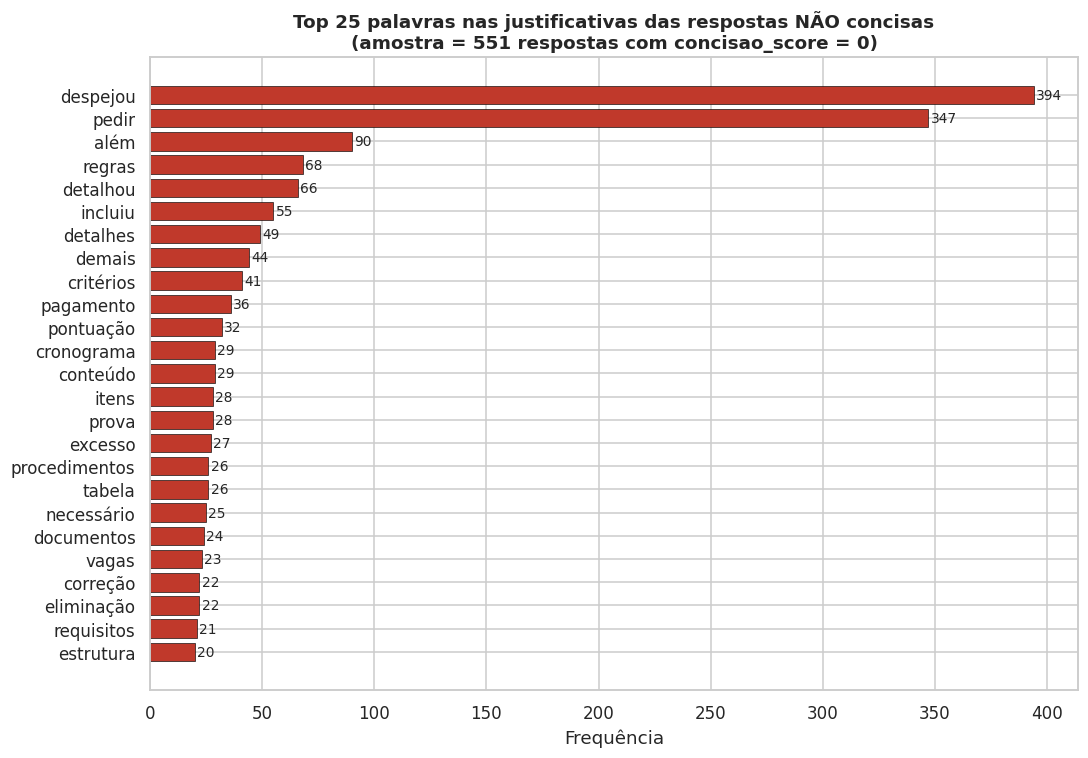


Exemplos de justificativas (despejos típicos):
  • despejou documentos, prazos e recursos sem pedir
  • incluiu desenvolvimento e mobilidade sem pedir
  • despejou conteúdos e correção sem pedir
  • despejou regras e itens proibidos sem pedir
  • acrescentou contatos e atribuições além do necessário
  • detalhou características da prova sem pedir
  • despejou requisitos remuneração e vagas sem pedir
  • despejou regras e comparativo de outros perfis
  • despejou tabela, taxa, prova e resultado sem pedir
  • despejou procedimento, período e punição sem pedir
  • despejou cronograma e procedimentos sem pedir
  • despejou turnos, aviso e sugestão sem pedir


In [4]:
nao_conc = df[df.concisao_score == 0].copy()
print(f'Respostas não concisas: {len(nao_conc)} ({len(nao_conc)/len(df):.1%} do total)')

# Frequência de palavras-chave nas justificativas
STOPWORDS = set('o a os as e de da do em um uma para por com sem que se na no nas nos ao aos'.split())

def tokenize_jus(s):
    s = str(s).lower()
    return [w for w in re.findall(r'[a-zçãáéíóúâêôà]+', s)
            if len(w) > 3 and w not in STOPWORDS]

contagem = Counter()
for j in nao_conc['justificativa_concisao'].dropna():
    contagem.update(tokenize_jus(j))

top = pd.DataFrame(contagem.most_common(25), columns=['palavra','freq'])

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top['palavra'][::-1], top['freq'][::-1], color='#c0392b',
               edgecolor='black', linewidth=0.4)
for b, v in zip(bars, top['freq'].values[::-1]):
    ax.text(v+1, b.get_y()+b.get_height()/2, str(v), va='center', fontsize=9)
ax.set_xlabel('Frequência')
ax.set_title('Top 25 palavras nas justificativas das respostas NÃO concisas\n'
             f'(amostra = {len(nao_conc)} respostas com concisao_score = 0)')
plt.tight_layout(); plt.show()

print('\nExemplos de justificativas (despejos típicos):')
for j in nao_conc['justificativa_concisao'].dropna().sample(min(12, len(nao_conc)), random_state=7):
    print(f'  • {j}')


## 4. Quanto tamanho de resposta acompanha a perda de concisão?

A concisão **não foi derivada** de tokens, mas naturalmente esperamos que respostas
com `concisao_score = 0` sejam mais longas. Vamos confirmar e quantificar.


Mediana de tokens — concisa:     114
Mediana de tokens — NÃO concisa: 309
Razão de medianas: 2.71×
Mann-Whitney U: p = 7.90e-166
Cliff's δ = +0.827  (|δ|>0.474 = grande)


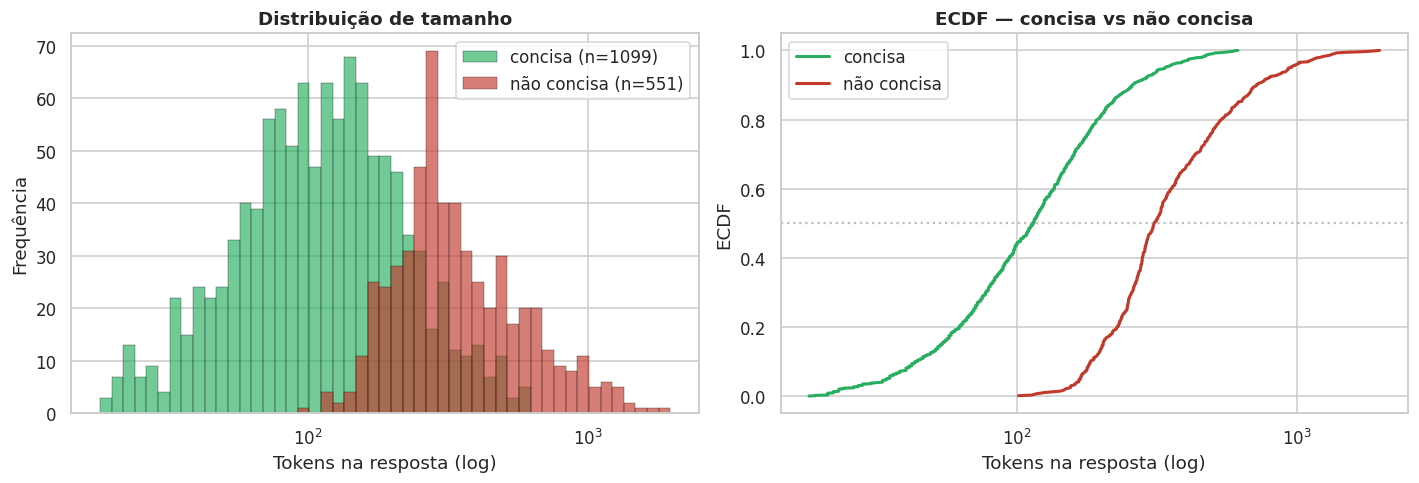

In [5]:
def cliffs_delta(a, b):
    from scipy.stats import rankdata
    a = np.asarray(a, float); b = np.asarray(b, float)
    if len(a)==0 or len(b)==0: return np.nan
    combined = np.concatenate([a, b])
    ranks = rankdata(combined)
    ua = ranks[:len(a)].sum() - len(a)*(len(a)+1)/2
    return 2*ua / (len(a)*len(b)) - 1

tok_concisa = df[df.concisao_score == 1]['resposta_tokens_tiktoken']
tok_nao     = df[df.concisao_score == 0]['resposta_tokens_tiktoken']

u, p = stats.mannwhitneyu(tok_nao, tok_concisa, alternative='greater')
delta = cliffs_delta(tok_nao.values, tok_concisa.values)

print(f'Mediana de tokens — concisa:     {tok_concisa.median():.0f}')
print(f'Mediana de tokens — NÃO concisa: {tok_nao.median():.0f}')
print(f'Razão de medianas: {tok_nao.median()/tok_concisa.median():.2f}×')
print(f'Mann-Whitney U: p = {p:.2e}')
print(f"Cliff's δ = {delta:+.3f}  (|δ|>0.474 = grande)")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
lo = max(df.resposta_tokens_tiktoken.min(), 1)
hi = df.resposta_tokens_tiktoken.max()
bins = np.logspace(np.log10(lo), np.log10(hi), 50)
axes[0].hist(tok_concisa, bins=bins, alpha=0.65, label=f'concisa (n={len(tok_concisa)})',
             color='#27ae60', edgecolor='black', linewidth=0.3)
axes[0].hist(tok_nao,     bins=bins, alpha=0.65, label=f'não concisa (n={len(tok_nao)})',
             color='#c0392b', edgecolor='black', linewidth=0.3)
axes[0].set_xscale('log')
axes[0].set_xlabel('Tokens na resposta (log)'); axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição de tamanho')
axes[0].legend()

# ECDF
for vals, cor, lbl in [(tok_concisa, '#27ae60', 'concisa'),
                       (tok_nao,     '#c0392b', 'não concisa')]:
    x = np.sort(vals); y = np.arange(1, len(x)+1)/len(x)
    axes[1].plot(x, y, color=cor, linewidth=2, label=lbl)
axes[1].set_xscale('log')
axes[1].set_xlabel('Tokens na resposta (log)'); axes[1].set_ylabel('ECDF')
axes[1].set_title('ECDF — concisa vs não concisa')
axes[1].legend()
axes[1].axhline(0.5, ls=':', color='gray', alpha=0.5)

plt.tight_layout(); plt.show()


## 5. Resposta concisa "perde" correção? Cruzamento 2×2

Tese a testar: **concisão custa correção?**


Tabela cruzada — contagens:
avaliacao_final  0.0  0.5   1.0  total
concisao_score                        
0                  3   43   505    551
1                 17   90   992   1099
total             20  133  1497   1650

% dentro de cada linha (condicional a concisao_score):
avaliacao_final  0.0  0.5   1.0
concisao_score                 
0                0.5  7.8  91.7
1                1.5  8.2  90.3

χ² test (concisão × avaliacao_final): χ² = 3.19, p = 2.031e-01
p alto = concisão e correção são razoavelmente independentes
p baixo = há associação estatisticamente significativa


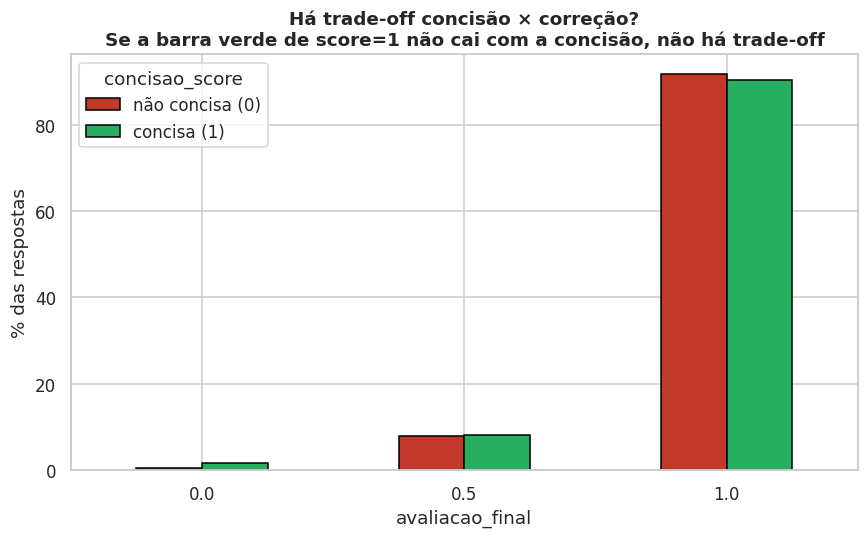


Delta de avaliacao_final (concisa − não concisa) por modelo:
           modelo  aval_quando_concisa  aval_quando_nao_conc  delta
     gpt-5.4-mini                0.909                 0.500  0.409
          gpt-5.4                0.969                 0.750  0.219
       std_claude                1.000                 0.945  0.055
      gpt-4o-mini                0.914                 0.882  0.031
  claude-opus-4-7                0.986                 0.968  0.019
 claude-haiku-4-5                0.938                 0.936  0.002
deepseek-v4-flash                0.970                 0.970  0.001
          gpt-5.5                0.997                 1.000 -0.003
  deepseek-v4-pro                0.958                 0.968 -0.011
claude-sonnet-4-6                0.963                 0.979 -0.016
      std_chatgpt                0.877                   NaN    NaN

Note: delta>0 ⇒ quando o modelo é conciso, ele acerta MAIS — quebra a tese do trade-off.


In [6]:
ct = pd.crosstab(df['concisao_score'], df['avaliacao_final'], margins=True, margins_name='total')
ct_pct = pd.crosstab(df['concisao_score'], df['avaliacao_final'], normalize='index')*100

print('Tabela cruzada — contagens:')
print(ct.to_string())
print('\n% dentro de cada linha (condicional a concisao_score):')
print(ct_pct.round(1).to_string())

# Teste qui-quadrado
chi2, p_chi, _, _ = stats.chi2_contingency(
    pd.crosstab(df['concisao_score'], df['avaliacao_final']))
print(f'\nχ² test (concisão × avaliacao_final): χ² = {chi2:.2f}, p = {p_chi:.3e}')
print('p alto = concisão e correção são razoavelmente independentes')
print('p baixo = há associação estatisticamente significativa')

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ct_pct.T.plot(kind='bar', stacked=False, ax=ax,
              color={1: '#27ae60', 0: '#c0392b'}, edgecolor='black')
ax.set_xlabel('avaliacao_final'); ax.set_ylabel('% das respostas')
ax.set_title('Há trade-off concisão × correção?\n'
             'Se a barra verde de score=1 não cai com a concisão, não há trade-off')
ax.legend(title='concisao_score', labels=['não concisa (0)','concisa (1)'])
plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

# Por modelo, é o mesmo padrão?
combo = (df.groupby('modelo')
         .apply(lambda g: pd.Series({
             'aval_quando_concisa':  g.loc[g.concisao_score==1,'avaliacao_final'].mean() if (g.concisao_score==1).any() else np.nan,
             'aval_quando_nao_conc': g.loc[g.concisao_score==0,'avaliacao_final'].mean() if (g.concisao_score==0).any() else np.nan,
             'delta': (g.loc[g.concisao_score==1,'avaliacao_final'].mean() if (g.concisao_score==1).any() else np.nan)
                    - (g.loc[g.concisao_score==0,'avaliacao_final'].mean() if (g.concisao_score==0).any() else np.nan),
         }), include_groups=False)
         .round(3).reset_index().sort_values('delta', ascending=False))
print('\nDelta de avaliacao_final (concisa − não concisa) por modelo:')
print(combo.to_string(index=False))
print('\nNote: delta>0 ⇒ quando o modelo é conciso, ele acerta MAIS — quebra a tese do trade-off.')


## 6. Concisão por categoria

Existem categorias de pergunta que naturalmente induzem respostas mais longas?


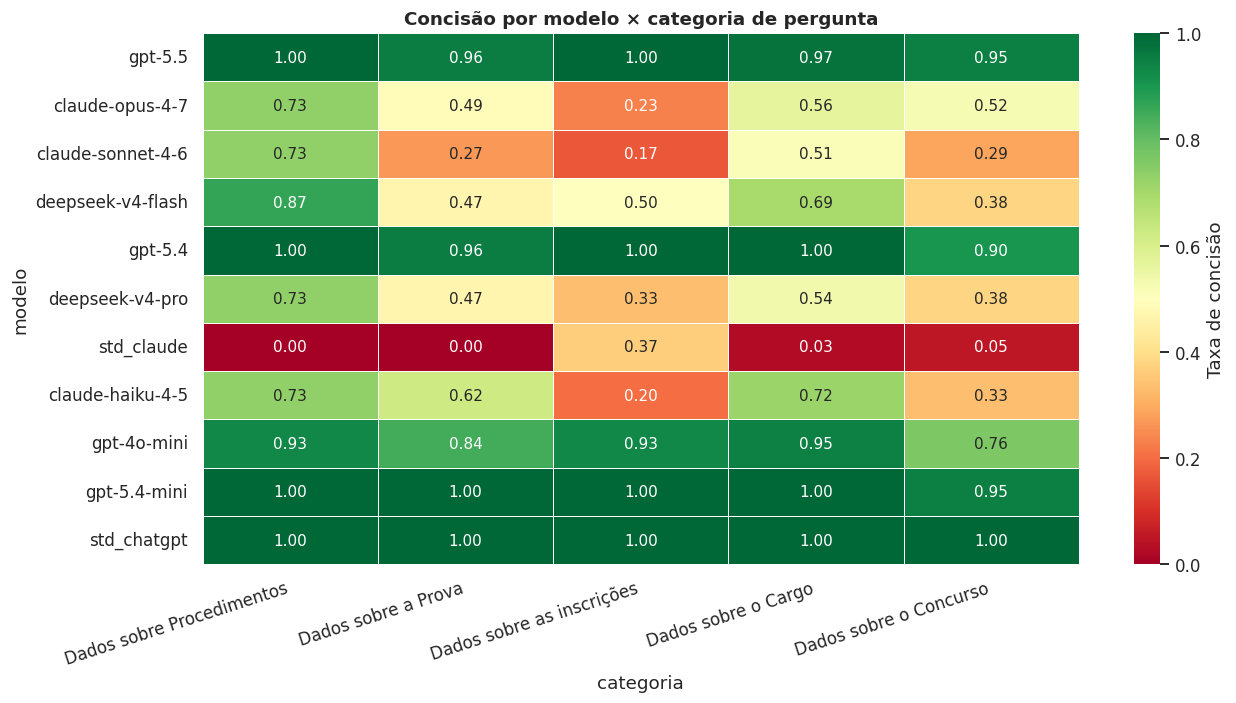


Taxa de concisão por categoria (média entre modelos):
                            mean  count
categoria                              
Dados sobre o Concurso     0.593    231
Dados sobre as inscrições  0.612    330
Dados sobre a Prova        0.642    495
Dados sobre o Cargo        0.725    429
Dados sobre Procedimentos  0.794    165


In [7]:
ordem_score = df.groupby('modelo')['avaliacao_final'].mean().sort_values(ascending=False).index

heat = df.pivot_table(index='modelo', columns='categoria',
                      values='concisao_score', aggfunc='mean').reindex(ordem_score)

fig, ax = plt.subplots(figsize=(12, 6.5))
sns.heatmap(heat, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=1,
            cbar_kws={'label':'Taxa de concisão'}, linewidths=0.5, ax=ax)
ax.set_title('Concisão por modelo × categoria de pergunta')
plt.setp(ax.get_xticklabels(), rotation=18, ha='right')
plt.tight_layout(); plt.show()

print('\nTaxa de concisão por categoria (média entre modelos):')
print(df.groupby('categoria')['concisao_score'].agg(['mean','count']).round(3)
      .sort_values('mean').to_string())


## 7. Resumo

Padrão esperado pelos dados:

- **OpenAI** (família GPT 5.x e ChatGPT) é consistentemente a mais concisa
- **Anthropic** (família Claude) responde correto mas com muito mais despejo —
  particularmente o chat comercial `std_claude` (taxa de concisão extremamente baixa)
- A perda de concisão **não custa correção** — modelos concisos acertam tanto ou mais
- "Despejos" típicos: pagamento, isenção, devolução, etapas extras, contexto não pedido
